#### Vizualization of log-likelihood deltas between anchor and augmented reponse

In this experiment, we've analyzed the differences in log-likelihoods between an anchor (ground truth) response and an augmented response.
For a model $\theta_i$ where $i$ is the checkpoint index and chat (concatenated prompt and response) $x_k$ and augmented chat $\tilde x_k$,
we compute $\log p(x_k | \theta_i) - \log p(\tilde x_k | \theta_i)$.

Setup:

I've fine-tuned `Llama3.2-1B-Instruct` models with GRPO, GRPO-S and KL-Cov. Every 10 steps, I've saved a checkpoint. After training, I've loaded
the checkpoints into memory and evaluated them on three datasets:

- Error Augmented Behaviour Dataset `/u/rfechner/data/eic_gsm8k_generated/deltas.jsonl`
- Reasoning Strategy Augmented Behaviour Dataset `/u/rfechner/data/incomplete_reasoning_strategies/deltas.jsonl`
- Reasoning Type Augmented Behaviour Dataset `/u/rfechner/data/incomplete_reasoning_types/deltas.jsonl`

Each Dataset has the columns: 

- `prompt` : carries the chat to be given to the model. The chat includes ground truth or augmented response
- `behaviour` : either behaviour type or 'anchor' to flag ground truth log-probs.

We pass the chats to the validation routine of the `PPORayTrainer` class which is used by all upstream entrypoint modules such as `dapo_ray_trainer.py` or `entropy_ray_trainer.py` and save the log-probabilities for the assistants response. This yields a directory like `/ptmp/rfechner/out/exp03/llama_3.2_1b_instruct__grpo/val_jsonl` in which for each checkpoint $i$ we collected a file `i_precomp.jsonl` containing columns:

- `checkpoint_global_step` : step of the checkpoint (also present in the filename)
- `line_idx` or `index` : index of query
- `behaviour_type` : behaviour type, e.g. "calculation error" or "deduction" or "anchor". "anchor" specifies that the logprobs for this row are the ground truth logprobs.
- `logprobs` : Log-probs of shape (response_length,)
- `entropy` : Entropy of shape (reponse_length,)

Goal: Per Algorithm, Per behaviour type one graph; X-axis is checkpoints, Y-axis is log-odds between anchor and behaviours. The y-axis value is the mean over the behaviour type axis.

Difference for error behaviour/ reasoning types/streategies. For error types:

1) Load single algorithm val_jsonl directory and all X_precomp.jsonl files.
    - Accumulate per row: logprobs and entropy.
    - split by 'line_idx', subtract "correct"==False from "correct"==True.
    => get odds and change in entropy immediately.


### Error Behaviour Analysis

In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
exp03_path = "/ptmp/rfechner/out/exp03"
methods = os.listdir(exp03_path)
methods

['llama_3.2_1b_instruct__kl-cov',
 'llama_3.2_1b_instruct__grpo',
 'llama_3.2_1b_instruct__grpo-s']

In [3]:
# get the timings per checkpoint interval of each method (taken straight from logs):
save_freq = 10
timings = {
    "llama_3.2_1b_instruct__grpo" : 356 * save_freq,
    "llama_3.2_1b_instruct__kl-cov" : 2168 * save_freq,
    "llama_3.2_1b_instruct__grpo-s" : 351 * save_freq,
}

In [4]:
per_methods = {}
for method in methods:
    path = os.path.join(exp03_path, method, 'val_jsonl')
    precomp_files = os.listdir(path)
    precomp_files = list(filter(lambda x: x.endswith('_precomp.jsonl'), precomp_files))
    precomp_files = list(sorted(precomp_files, key=lambda x: int(x.split("_")[0])))
    checkpoints = []
    for pfile in precomp_files:
        with open(os.path.join(path, pfile), 'r') as f:
            df = pd.read_json(f, lines=True)

            #accumulate per row:
            df['lpmean'] = df['logprobs'].apply(np.mean)
            df['entmean'] = df['entropy'].apply(np.mean)
            correct, incorrect = df[df['correct']], df[~df['correct']]
            correct = correct.sort_values(by='line_idx')
            incorrect = incorrect.sort_values(by='line_idx')
            

            lpdelta = correct['lpmean'].to_numpy() - incorrect['lpmean'].to_numpy()
            entdelta = correct['entmean'].to_numpy() - incorrect['entmean'].to_numpy()


            # group by question type and calculate means
            new = pd.DataFrame({'error_type' : correct['error_type'], 'lp' : lpdelta, 'e' : entdelta})

            means : pd.DataFrame = new.groupby('error_type').mean()
            checkpoints.append(means.to_dict(orient='dict'))
    per_methods[method] = checkpoints


In [5]:
import matplotlib.pyplot as plt

In [6]:
# data = per_methods

# # Correct extraction of all error types from both lp and e across all records
# error_types = sorted({
#     key
#     for method_records in data.values()
#     for rec in method_records
#     for key in set(rec.get("lp", {}).keys()) | set(rec.get("e", {}).keys())
# })

# print("Error types:", error_types)  # full list

# # Helper to set only first & last ticks for an axis, handling constant values
# def set_first_last_ticks(ax, x_vals, y_vals, xlabel_on_bottom=True):
#     # x ticks -> first and last
#     if len(x_vals) >= 2:
#         ax.set_xticks([x_vals[0], x_vals[-1]])
#     else:
#         ax.set_xticks([x_vals[0]])
#     # y ticks -> first and last of data range
#     y_min, y_max = np.nanmin(y_vals), np.nanmax(y_vals)
#     if np.isfinite(y_min) and np.isfinite(y_max):
#         if y_min == y_max:
#             ax.set_yticks([y_min])
#         else:
#             ax.set_yticks([y_min, y_max])
#     else:
#         ax.set_yticks([])

# # Minimal ink plotting per method
# for method, records in data.items():
#     n_err = len(error_types)
#     n_steps = len(records)
#     t = list(range(n_steps))

#     # Figure size depends on number of columns (error types)
#     fig_w = max(3 * n_err, 8)
#     fig_h = 5  # two rows stacked
#     fig, axes = plt.subplots(2, n_err, figsize=(fig_w, fig_h), sharex='col')
#     fig.suptitle(f"{method} — lp (row 1) and e (row 2) per error type", fontsize=12)

#     # Ensure axes is 2D array if n_err == 1
#     if n_err == 1:
#         axes = axes.reshape(2, 1)

#     for col_idx, err in enumerate(error_types):
#         # extract series, use np.nan for missing
#         lp_vals = [rec.get("lp", {}).get(err, np.nan) for rec in records]
#         e_vals  = [rec.get("e",  {}).get(err, np.nan) for rec in records]

#         # Row 0: lp
#         ax_lp = axes[0, col_idx]
#         ax_lp.plot(t, lp_vals, marker='o', linewidth=1, markersize=4)
#         ax_lp.set_title(err, fontsize=9, pad=4)
#         if col_idx == 0:
#             ax_lp.set_ylabel("lp", fontsize=9)
#         # minimal ink: hide top/right spines, keep left/bottom
#         ax_lp.spines['top'].set_visible(False)
#         ax_lp.spines['right'].set_visible(False)
#         ax_lp.spines['left'].set_visible(True)
#         ax_lp.spines['bottom'].set_visible(True)
#         # only first and last ticks
#         set_first_last_ticks(ax_lp, t, lp_vals)
#         # remove tick labels for interior columns (optional); keep them small
#         ax_lp.tick_params(axis='both', labelsize=8)
#         # Row 1: e
#         ax_e = axes[1, col_idx]
#         ax_e.plot(t, e_vals, marker='o', linewidth=1, markersize=4)
#         if col_idx == 0:
#             ax_e.set_ylabel("entropy", fontsize=9)
#         ax_e.spines['top'].set_visible(False)
#         ax_e.spines['right'].set_visible(False)
#         ax_e.spines['left'].set_visible(True)
#         ax_e.spines['bottom'].set_visible(True)
#         set_first_last_ticks(ax_e, t, e_vals)
#         ax_e.tick_params(axis='both', labelsize=8)

#         # Only show x tick labels on bottom row
#         ax_lp.set_xticklabels([])

#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

behaviour_types: ['Calculation Error', 'Context Value Error', 'Contradictory Step', 'Counting Error', 'Formula Confusion Error', 'Hallucination', 'Missing Step', 'Operator Error', 'Unit Conversion Error']


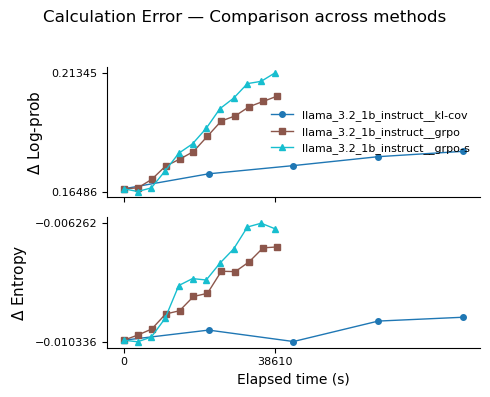

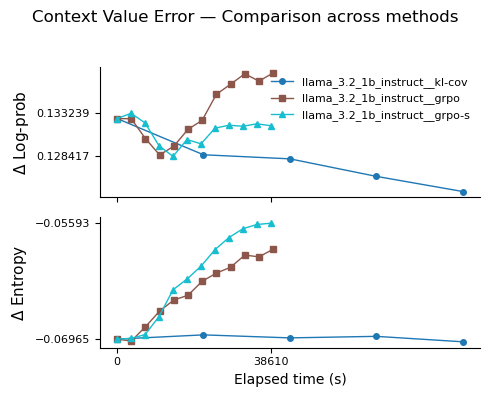

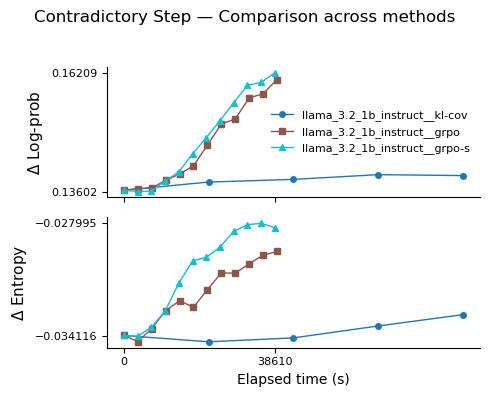

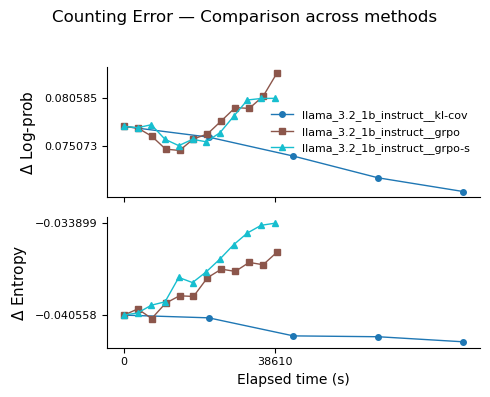

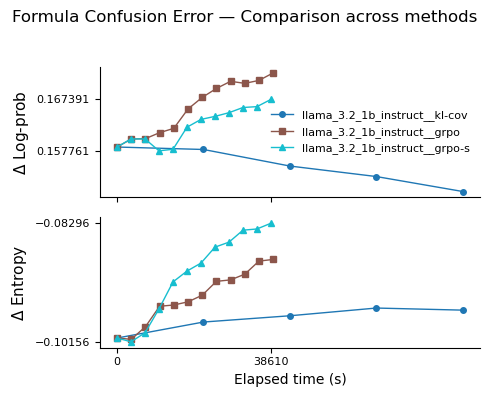

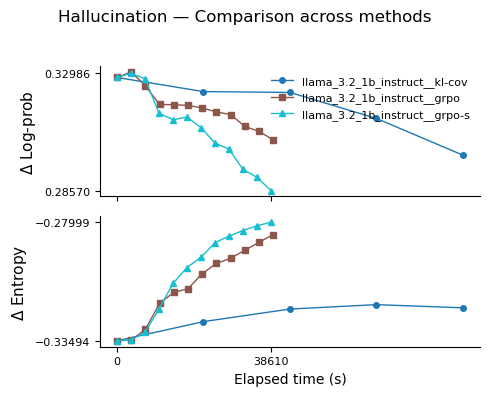

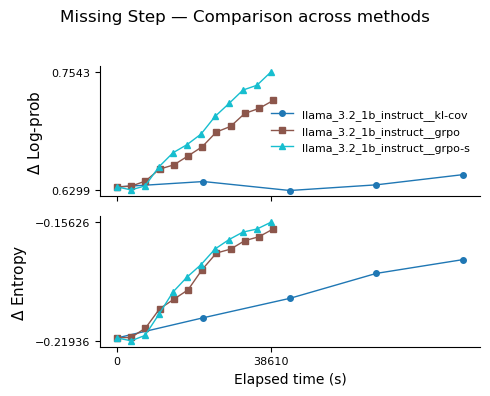

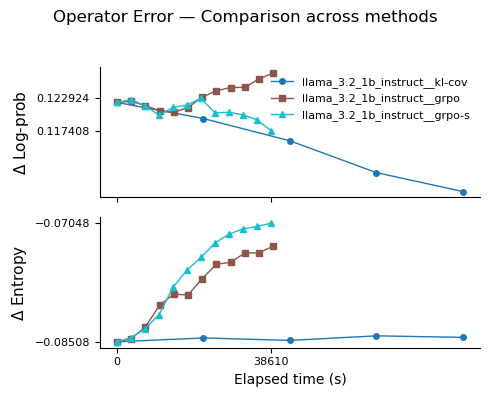

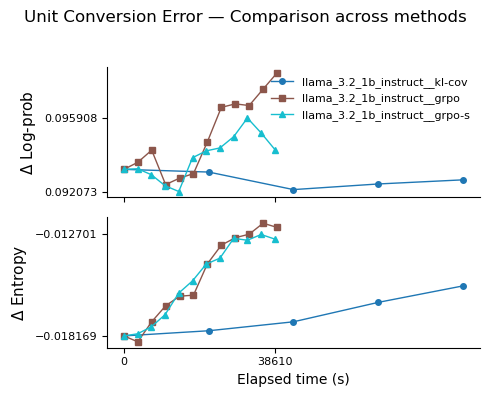

In [7]:
def plot(data: dict, time_per_step_s: dict[str, int] = None):
    """
    Plot ΔLog-prob (lp) and ΔEntropy (e) per behaviour type, comparing methods.

    Parameters
    ----------
    data : dict
        Structure: {method: [ {'lp': {...}, 'e': {...}}, ... ]}
    time_per_step_s : dict[str, float], optional
        Mapping of method -> time per step in seconds.
        If provided, each method's x-axis is rescaled by this value.
    """

    # Collect behaviour types from all methods and records (lp + e)
    behaviour_types = sorted({
        key
        for method_records in data.values()
        for rec in method_records
        for key in set(rec.get("lp", {}).keys()) | set(rec.get("e", {}).keys())
    })
    methods = list(data.keys())

    print("behaviour_types:", behaviour_types)

    # Helper: minimal tick labeling
    def set_first_last_ticks(ax, x_vals, y_vals):
        if len(x_vals) >= 2:
            ax.set_xticks([x_vals[0], x_vals[-1]])
        else:
            ax.set_xticks([x_vals[0]])
        y_min, y_max = np.nanmin(y_vals), np.nanmax(y_vals)
        if np.isfinite(y_min) and np.isfinite(y_max):
            if y_min == y_max:
                ax.set_yticks([y_min])
            else:
                ax.set_yticks([y_min, y_max])
        else:
            ax.set_yticks([])

    # Colors and markers per method for clarity
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    markers = ['o', 's', '^', 'D', 'x', 'v']

    # Plot per behaviour type
    for err in behaviour_types:
        fig, axes = plt.subplots(2, 1, figsize=(5, 4), sharex=True)
        fig.suptitle(f"{err} — Comparison across methods", fontsize=12)

        for method_idx, method in enumerate(methods):
            records = data[method]

            # ✅ Compute elapsed time per method
            if time_per_step_s and method in time_per_step_s:
                step_time = time_per_step_s[method]
                t = np.arange(len(records)) * step_time
                xlabel = "Elapsed time (s)"
            else:
                t = np.arange(len(records))
                xlabel = "Checkpoint index"

            lp_vals = [rec.get("lp", {}).get(err, np.nan) for rec in records]
            e_vals  = [rec.get("e", {}).get(err, np.nan) for rec in records]

            # Row 1: Δ Log-prob
            axes[0].plot(
                t, lp_vals,
                marker=markers[method_idx % len(markers)],
                color=colors[method_idx],
                lw=1, markersize=4,
                label=method
            )

            # Row 2: Δ Entropy
            axes[1].plot(
                t, e_vals,
                marker=markers[method_idx % len(markers)],
                color=colors[method_idx],
                lw=1, markersize=4,
                label=method
            )

        # Minimal ink styling
        for i, ax in enumerate(axes):
            for spine in ['top', 'right']:
                ax.spines[spine].set_visible(False)
            ax.tick_params(axis='both', labelsize=8)
            set_first_last_ticks(ax, t, [*np.nan_to_num(
                [rec.get("lp" if i == 0 else "e", {}).get(err, np.nan)
                 for rec in records])])
            ax.set_ylabel("$\Delta$ Log-prob" if i == 0 else "$\Delta$ Entropy", fontsize=11)

        axes[1].set_xlabel(xlabel, fontsize=10)
        axes[0].legend(fontsize=8, loc="best", frameon=False)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        
plot(per_methods, timings)

### Reasoning Type Analysis

In [8]:
exp06_path = "/ptmp/rfechner/out/exp06"
methods = os.listdir(exp06_path)
methods

['reasoning_strategies__llama_3.2_1b_instruct__grpo',
 'reasoning_types__llama_3.2_1b_instruct__grpo',
 'reasoning_types__llama_3.2_1b_instruct__kl-cov',
 'reasoning_strategies__llama_3.2_1b_instruct__kl-cov']

In [9]:
rs_paths = list(filter(lambda x: x.startswith('reasoning_strategies'), methods))
rt_paths = list(filter(lambda x: x.startswith('reasoning_types'), methods))
rs_paths, rt_paths

(['reasoning_strategies__llama_3.2_1b_instruct__grpo',
  'reasoning_strategies__llama_3.2_1b_instruct__kl-cov'],
 ['reasoning_types__llama_3.2_1b_instruct__grpo',
  'reasoning_types__llama_3.2_1b_instruct__kl-cov'])

In [10]:
def collect_data_new_schema(paths : list[str]) -> dict:
    per_methods = {}
    for path in paths:
        assert os.path.isdir(path)
        basename = os.path.basename(path)
        method = '__'.join(basename.split('__')[1:]) if '__' in basename else basename

        validation_dir_path = os.path.join(path, 'val_jsonl')
        precomp_files = os.listdir(validation_dir_path)
        precomp_files = list(filter(lambda x: x.endswith('_precomp.jsonl'), precomp_files))
        precomp_files = list(sorted(precomp_files, key=lambda x: int(x.split("_")[0])))
        checkpoints = []
        for pfile in precomp_files:
            with open(os.path.join(validation_dir_path, pfile), 'r') as f:
                df = pd.read_json(f, lines=True)

                #accumulate per row:
                df['lpmean'] = df['logprobs'].apply(np.mean)
                df['entmean'] = df['entropy'].apply(np.mean)
                
                rows = []
                for index, group_df in df.groupby('index'):
                    # find anchor
                    anchor_row = group_df[group_df['behaviour_type'] == 'anchor']
                    other_rows = group_df[group_df['behaviour_type'] != 'anchor']

                    # subtract others from anchor
                    lpdelta = anchor_row['lpmean'].to_numpy() - other_rows['lpmean'].to_numpy()
                    entdelta = anchor_row['lpmean'].to_numpy() - other_rows['entmean'].to_numpy()
                    new_rows = [{'behaviour_type' : bt, 'lp' : l, 'e' : e } for bt, l, e in zip(other_rows['behaviour_type'], lpdelta, entdelta)]
                    rows.extend(new_rows)

                # group by question type and calculate means
                new = pd.DataFrame(rows)

                means : pd.DataFrame = new.groupby('behaviour_type').mean()
                checkpoints.append(means.to_dict(orient='dict'))
        per_methods[method] = checkpoints
    return per_methods


In [11]:
rs_paths_abs = [os.path.join(exp06_path, p) for p in rs_paths]
data = collect_data_new_schema(rs_paths_abs)

behaviour_types: ['Analogical Mapping', 'Backtracking', 'Decomposition', 'Pattern Recognition', 'Simplification', 'Trials', 'Verification']


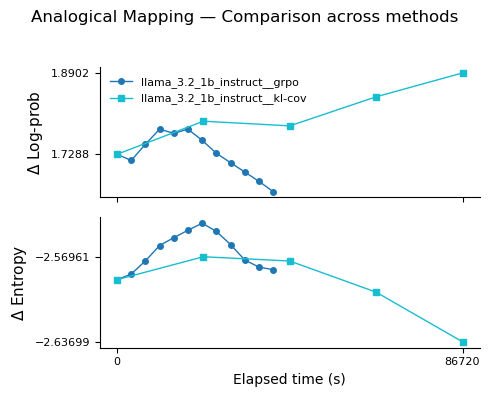

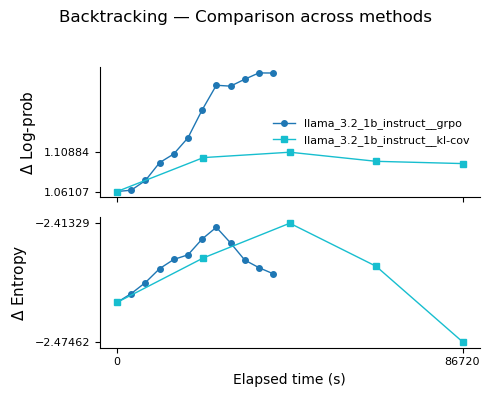

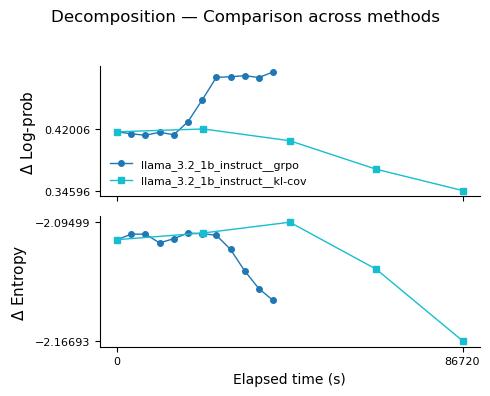

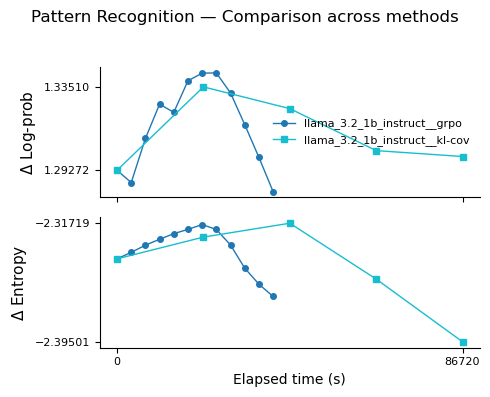

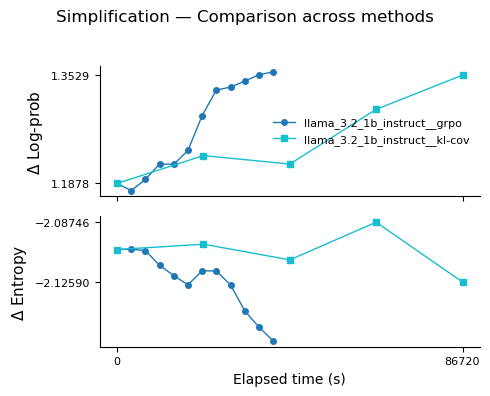

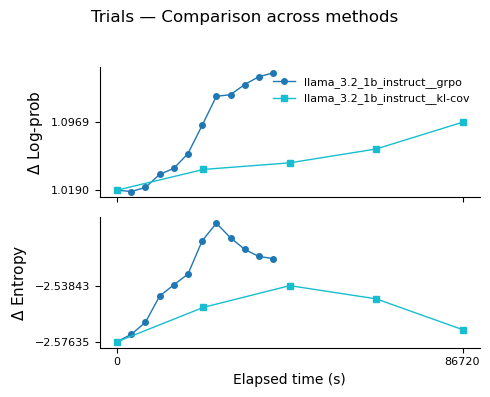

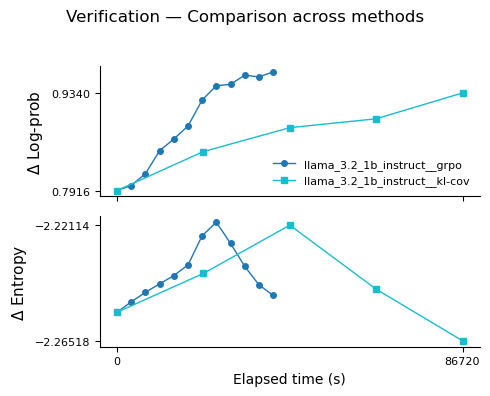

In [12]:
plot(data, timings)

behaviour_types: ['Abductive Reasoning', 'Analogical Reasoning', 'Deductive Reasoning', 'Inductive Reasoning']


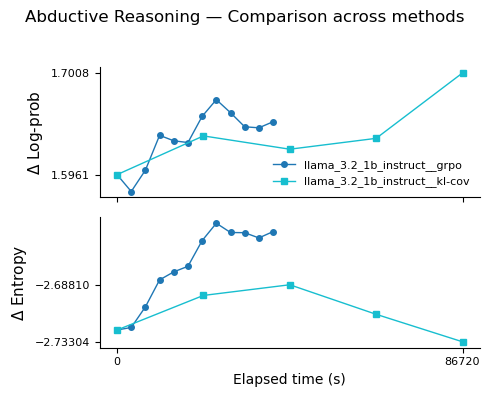

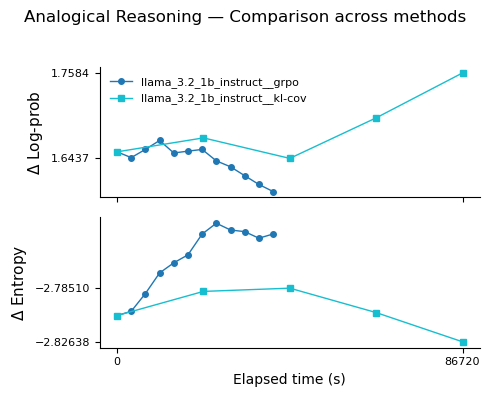

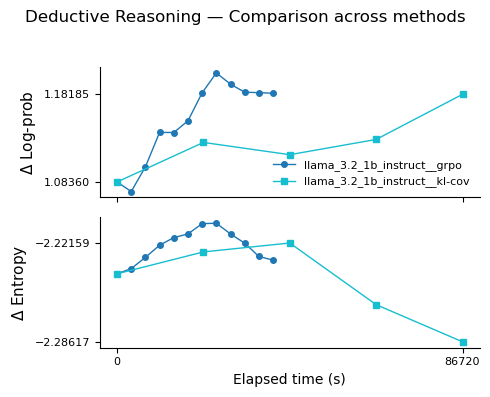

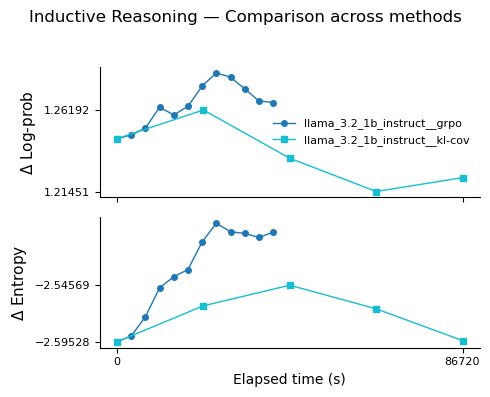

In [13]:
rt_paths_abs = [os.path.join(exp06_path, p) for p in rt_paths]
data = collect_data_new_schema(rt_paths_abs)
plot(data, timings)